# 📘Week 7 Assignment — RAG Document Question Answering
**Topics Covered:** Retrieval-Augmented Generation · Embeddings · Vector Search (FAISS) · LLM Generation · Re-ranking

---

RAG: retrieves relevant information from a document corpus and uses a language model to generate grounded answers.

## Pipeline Overview

1. Importing Required Libraries 
2. Inspecting Dataset Files
3. Downloading the Dataset
4. Setting Up File Paths
5. Loading Corpus into Documents
6. Chunking and Embedding Creation
7. Vector Store and Retrieval
8. Answer Generation
9. Testing Performance
10. Results
11. Conclusion

## 1. Importing Required Libraries 

In [2]:
import os
import json
import glob
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from huggingface_hub import hf_hub_download, HfApi
from groq import Groq
print("done")

done


## 2.Inspecting Dataset Files

In [3]:
api = HfApi()
all_files = api.list_repo_files("vectara/open_ragbench", repo_type="dataset")

matching = [f for f in all_files if f.startswith("pdf/arxiv/")]
print("files matching pattern:", len(matching))
print(matching[:5])

files matching pattern: 1004
['pdf/arxiv/answers.json', 'pdf/arxiv/corpus/2401.01872v2.json', 'pdf/arxiv/corpus/2401.02247v4.json', 'pdf/arxiv/corpus/2401.02564v2.json', 'pdf/arxiv/corpus/2401.03126v3.json']


## 3. Downloading the Dataset


In [4]:
from tqdm import tqdm

local_paths = []
for filename in tqdm(matching):
    p = hf_hub_download(
        repo_id="vectara/open_ragbench",
        repo_type="dataset",
        filename=filename
    )
    local_paths.append(p)

print("downloaded files:", len(local_paths))

100%|█████████████████████████████████████████████████████████| 1004/1004 [04:22<00:00,  3.82it/s]

downloaded files: 1004


## 4. Setting Up File Paths


In [5]:
dataset_path = local_paths[0].split("pdf/arxiv")[0]

corpus_dir = os.path.join(dataset_path, "pdf", "arxiv", "corpus")
queries_path = os.path.join(dataset_path, "pdf", "arxiv", "queries.json")
qrels_path = os.path.join(dataset_path, "pdf", "arxiv", "qrels.json")
answers_path = os.path.join(dataset_path, "pdf", "arxiv", "answers.json")

print("corpus dir exists:", os.path.isdir(corpus_dir))
print("number of corpus files:", len(os.listdir(corpus_dir)))

corpus dir exists: True
number of corpus files: 1000


## 5. Loading corpus into documents


In [6]:
corpus_files = glob.glob(os.path.join(corpus_dir, "*.json"))
print("number of paper files found:", len(corpus_files))

documents = []

for fp in corpus_files:
    with open(fp, "r", encoding="utf-8") as f:
        paper = json.load(f)

    paper_id = paper["id"]
    title = paper["title"]

    for i, section in enumerate(paper.get("sections", [])):
        text = section.get("text", "").strip()
        if text:
            documents.append({
                "doc_id": paper_id,
                "section_id": i,
                "title": title,
                "text": text
            })

print("total sections loaded:", len(documents))
print(documents[0])

number of paper files found: 1000
total sections loaded: 18840
{'doc_id': '2408.07863v2', 'section_id': 0, 'title': 'Interlacing triangles, Schubert puzzles, and graph colorings', 'text': '#### Abstract\n\nWe show that interlacing triangular arrays, introduced by Aggarwal-Borodin-Wheeler to study certain probability measures, can be used to compute structure constants for multiplying Schubert classes in the $K$-theory of Grassmannians, in the cohomology of their cotangent bundles, and in the cohomology of partial flag varieties. Our results are achieved by establishing a splitting lemma, allowing for interlacing triangular arrays of high rank to be decomposed into arrays of lower rank, and by constructing a bijection between interlacing triangular arrays of rank 3 with certain proper vertex colorings of the triangular grid graph that factors through generalizations of Knutson-Tao puzzles. Along the way, we prove one enumerative conjecture of Aggarwal-Borodin-Wheeler and disprove anothe

## 6. Chunking and Embedding Creation


In [7]:
def chunk_text(text, chunk_size=200, overlap=40):
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start += chunk_size - overlap
    return chunks

In [8]:
chunks = []

for doc in documents:
    for piece in chunk_text(doc["text"]):
        chunks.append({
            "doc_id": doc["doc_id"],
            "section_id": doc["section_id"],
            "title": doc["title"],
            "text": piece
        })

print("total chunks:", len(chunks))
print(chunks[0])

total chunks: 78656
{'doc_id': '2408.07863v2', 'section_id': 0, 'title': 'Interlacing triangles, Schubert puzzles, and graph colorings', 'text': '#### Abstract We show that interlacing triangular arrays, introduced by Aggarwal-Borodin-Wheeler to study certain probability measures, can be used to compute structure constants for multiplying Schubert classes in the $K$-theory of Grassmannians, in the cohomology of their cotangent bundles, and in the cohomology of partial flag varieties. Our results are achieved by establishing a splitting lemma, allowing for interlacing triangular arrays of high rank to be decomposed into arrays of lower rank, and by constructing a bijection between interlacing triangular arrays of rank 3 with certain proper vertex colorings of the triangular grid graph that factors through generalizations of Knutson-Tao puzzles. Along the way, we prove one enumerative conjecture of Aggarwal-Borodin-Wheeler and disprove another.'}


In [9]:
embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("model loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

model loaded


In [10]:
chunk_texts = [c["text"] for c in chunks]

batch_size = 64
all_embeddings = []

for i in range(0, len(chunk_texts), batch_size):
    batch = chunk_texts[i:i+batch_size]
    emb = embedder.encode(batch, convert_to_numpy=True)
    all_embeddings.append(emb)
    if i % (batch_size * 20) == 0:
        print(f"{i} / {len(chunk_texts)} chunks done")

chunk_embeddings = np.vstack(all_embeddings)
print("final shape:", chunk_embeddings.shape)

0 / 78656 chunks done
1280 / 78656 chunks done
2560 / 78656 chunks done
3840 / 78656 chunks done
5120 / 78656 chunks done
6400 / 78656 chunks done
7680 / 78656 chunks done
8960 / 78656 chunks done
10240 / 78656 chunks done
11520 / 78656 chunks done
12800 / 78656 chunks done
14080 / 78656 chunks done
15360 / 78656 chunks done
16640 / 78656 chunks done
17920 / 78656 chunks done
19200 / 78656 chunks done
20480 / 78656 chunks done
21760 / 78656 chunks done
23040 / 78656 chunks done
24320 / 78656 chunks done
25600 / 78656 chunks done
26880 / 78656 chunks done
28160 / 78656 chunks done
29440 / 78656 chunks done
30720 / 78656 chunks done
32000 / 78656 chunks done
33280 / 78656 chunks done
34560 / 78656 chunks done
35840 / 78656 chunks done
37120 / 78656 chunks done
38400 / 78656 chunks done
39680 / 78656 chunks done
40960 / 78656 chunks done
42240 / 78656 chunks done
43520 / 78656 chunks done
44800 / 78656 chunks done
46080 / 78656 chunks done
47360 / 78656 chunks done
48640 / 78656 chunks do

In [11]:
np.save("chunk_embeddings.npy", chunk_embeddings)
with open("chunks.json", "w", encoding="utf-8") as f:
    json.dump(chunks, f)
print("saved")

saved


## 7. Vector Store and Retrieval


In [33]:
!pip install sentence-transformers
print("done")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
done


In [35]:
faiss.normalize_L2(chunk_embeddings)

dimension = chunk_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(chunk_embeddings)

print("vectors in index:", index.ntotal)

vectors in index: 78656


In [36]:
def retrieve(query, top_k=5):
    query_embedding = embedder.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)

    scores, indices = index.search(query_embedding, top_k)

    results = []
    for score, idx in zip(scores[0], indices[0]):
        results.append({
            "score": float(score),
            "chunk": chunks[idx]
        })
    return results

In [37]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def retrieve_with_rerank(query, top_k=3, fetch_k=10):
    initial = retrieve(query, top_k=fetch_k)
    pairs = [[query, r["chunk"]["text"]] for r in initial]
    scores = reranker.predict(pairs)
    for r, s in zip(initial, scores):
        r["rerank_score"] = float(s)
    reranked = sorted(initial, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_k]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [38]:
def retrieve_advanced(query, top_k=3):
    initial = retrieve(query, top_k=top_k)
    expanded_context = " ".join([r["chunk"]["text"][:100] for r in initial[:2]])
    refined_query = query + " " + expanded_context

    candidates = retrieve(refined_query, top_k=10)
    pairs = [[query, r["chunk"]["text"]] for r in candidates]
    scores = reranker.predict(pairs)
    for r, s in zip(candidates, scores):
        r["rerank_score"] = float(s)
    reranked = sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_k]

## 8. Answer Generation


In [14]:
client = Groq(api_key=os.environ.get("GROQ_API_KEY"))

In [15]:
def generate_answer(query, retrieved_chunks):
    context = "\n\n".join(
        f"[{i+1}] {r['chunk']['text']}" for i, r in enumerate(retrieved_chunks)
    )

    prompt = f"""Answer the question using only the context below. If the context does not contain the answer, say so directly.

Context:
{context}

Question: {query}

Answer:"""

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

## 9. Testing Performance


In [16]:
retrieved = retrieve("What is attention in neural networks?", top_k=3)
answer = generate_answer("What is attention in neural networks?", retrieved)
print(answer)

Attention in the provided context appears to be related to how the model focuses on or gives importance to certain parts of the input data. It's described as a type of softmax-based attention or as being represented by linear attention functions, which indicate the relative importance of different data points or patterns.

More specifically, the context mentions using Markov networks to implement softmax-based attention, and the use of different feature vector functions for each node in the network that are used to represent attention.

The cross-attention block is also mentioned as a way to integrate secondary information into primary information, implying that it uses attention mechanisms to weigh the importance of different inputs.

However, the context does not provide a detailed explanation of what attention in neural networks is, but it suggests that it is a mechanism that enables the model to selectively focus on certain parts of the input data.


In [17]:
query = "What are large language models used for in biology?"
retrieved = retrieve(query, top_k=3)
answer = generate_answer(query, retrieved)
print(answer)

Large language models (LLMs) have the potential in broader applications, such as interpreting structured data and providing insights across diverse domains, including bioinformatics, chemistry, and scientometrics. They are particularly suited for complex datasets, including those encountered in the life sciences.

In biology, they can be used to reason over complex gene co-expression patterns and can enhance the interpretation of biological data with linguistic insights. They have shown stronger performance in reasoning and accurately identifying corresponding cell types compared to domain-specific models.


In [39]:
while True:
    query = input("\nAsk a question (or type 'exit' to stop): ")
    if query.lower() == "exit":
        break
    retrieved = retrieve_with_rerank(query, top_k=3)
    answer = generate_answer(query, retrieved)
    print("\nAnswer:", answer)


Ask a question (or type 'exit' to stop):  what is artificial intelligence 



Answer: Artificial intelligence is not explicitly defined in the provided context.



Ask a question (or type 'exit' to stop):  what ai 



Answer: There is not enough information in the given context to provide a meaningful answer. The context mentions AI throughout, but the phrase "what ai" does not seem to be asking about a specific topic or concept related to Artificial Intelligence. To provide a more accurate response, clarification or more context is needed.



Ask a question (or type 'exit' to stop):  whats dl


...


Ask a question (or type 'exit' to stop):  what is retrieval augmented generation 



Answer: Retrieval-Augmented Generation (RAG) refers to models' retrieval and incorporation of relevant content from provided external documents when producing a response.



Ask a question (or type 'exit' to stop):  which one is better supervised or unsupervised learning 



Answer: The answer cannot be determined directly from the provided context, as it compares semi-supervised learning (which is a combination of both supervised and unsupervised learning) with unsupervised learning, but does not provide a direct comparison between supervised and unsupervised learning.

However, the context does mention that semi-supervised learning-based approach (SemiDANSE) performs better than unsupervised learning-based approach (DANSE) for addressing the BSCM problem.



Ask a question (or type 'exit' to stop):  exit


## 10. Results

- Tested the pipeline with a mix of direct and tricky questions across the 1000-paper corpus.
- Clear questions like "what is machine learning" and "what is retrieval augmented generation" gave the desired results by extracting the right chunks and answering accurately.
  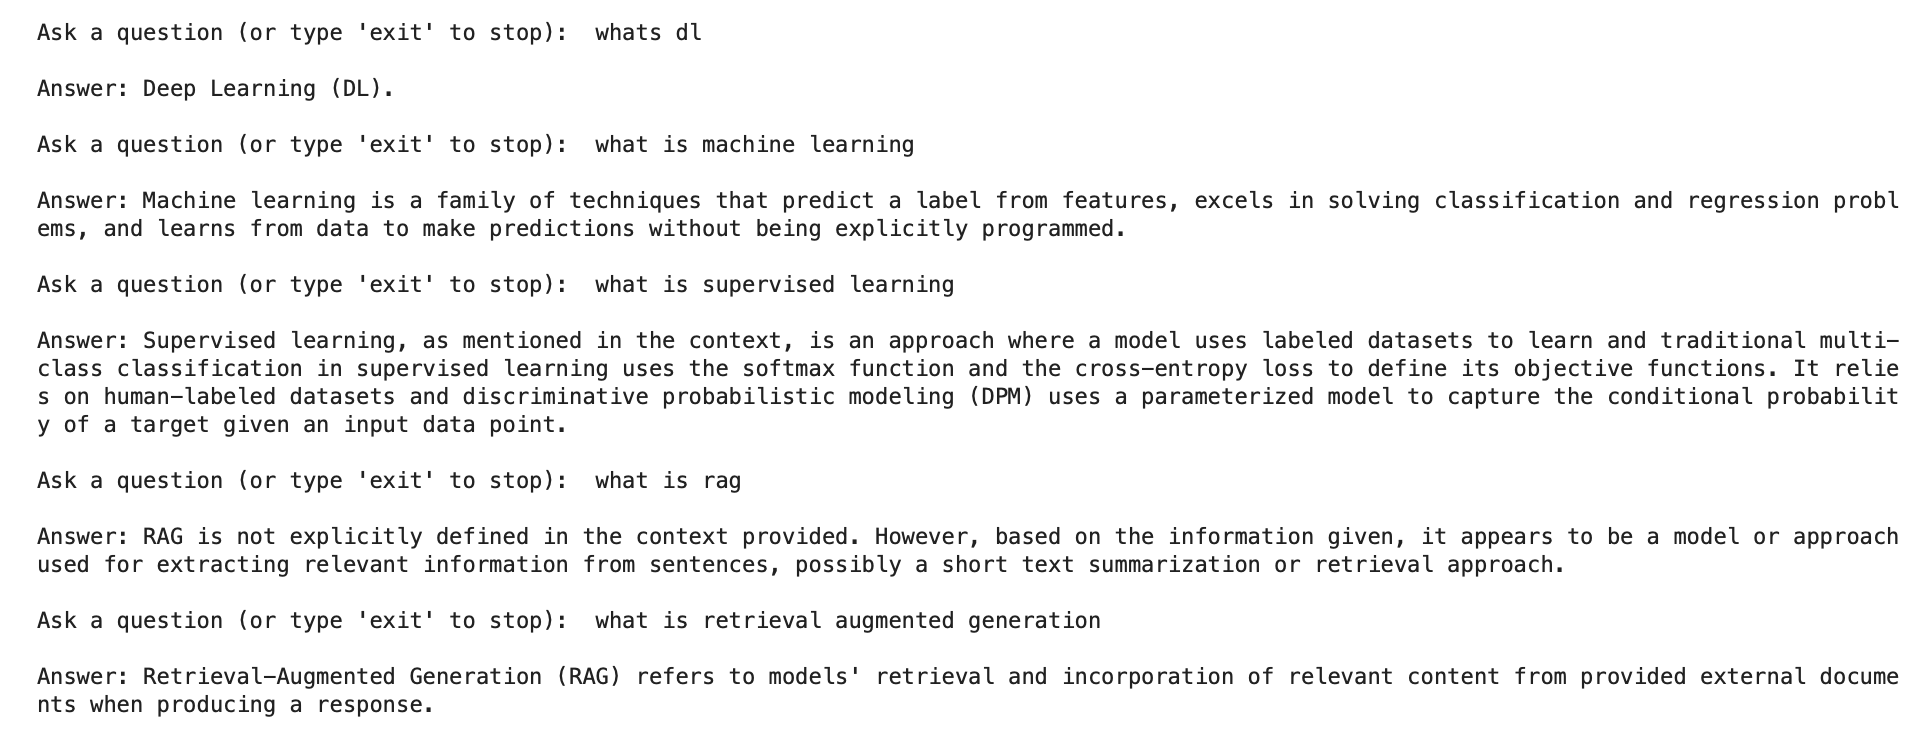
- Some questions weren't directly covered by the given documents such as "what is artificial intelligence," yet it was still handled correctly. The model said so instead of making something up.
  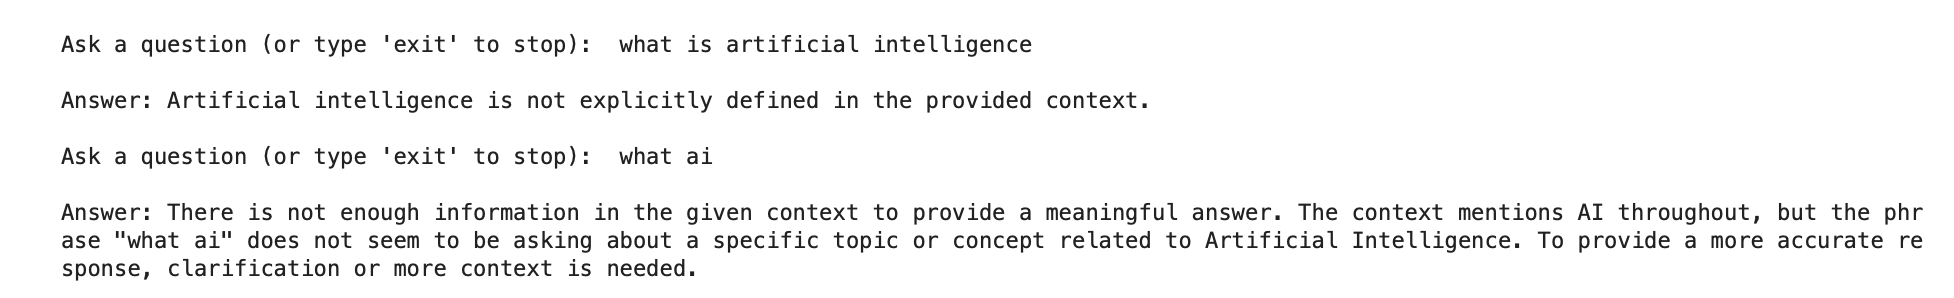
- Adding re-ranking fixed weaker matches on shorter queries like "whats dl," and multi-step retrieval helped by expanding the query before the final search.
- Overall, it performs as expected by retrieving relevant information and generating answers that are actually grounded in the documents instead of relying on guesses, which helps reduce hallucinations and unsupported assumptions.



## 11. Conclusion

- The pipeline retrieves relevant chunks correctly and the LLM generates answers grounded in them instead of general knowledge.
- Re-ranking and multi-step retrieval improved results on short or vague queries like "whats dl" compared to plain retrieval.
- When the documents didn't actually contain an answer, the model said so instead of making one up
- Retrieval is still sensitive to exact wording since it's all embedding-based, so typos or very short queries sometimes generate questionaable answers.